In [1]:
!uv pip install -r requirements.txt

Audited 6 packages in 74ms


In [3]:
import torch
import torch.nn as nn
import open_clip
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
)
import umap
import hdbscan


class BioCLIPReID(nn.Module):
    def __init__(self, checkpoint_path=None, num_heads=8):
        super().__init__()
        # Load architecture
        bioclip, _, _ = open_clip.create_model_and_transforms(
            "hf-hub:imageomics/bioclip"
        )
        self.backbone = bioclip.visual
        self.embed_dim = 768

        # Neck components
        self.mhsa = nn.MultiheadAttention(
            embed_dim=self.embed_dim, num_heads=num_heads, batch_first=True
        )
        self.bottleneck = nn.BatchNorm1d(self.embed_dim)
        self.bottleneck.bias.requires_grad_(False)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Load weights AFTER defining architecture
        if checkpoint_path and Path(checkpoint_path).exists():
            print(f"Loading weights from {checkpoint_path}...")
            state_dict = torch.load(checkpoint_path, map_location="cpu")
            # Handle potential 'visual.' vs 'backbone.' prefix mismatch
            state_dict = {
                k.replace("visual.", "backbone."): v for k, v in state_dict.items()
            }
            self.load_state_dict(state_dict, strict=False)

    def forward(self, x):
        # Manual Patch Extraction for ViT-B-16
        x = self.backbone.conv1(x)
        x = x.reshape(x.shape[0], x.shape[1], -1).transpose(1, 2)
        x = torch.cat(
            [
                self.backbone.class_embedding.to(x.dtype)
                + torch.zeros(
                    x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device
                ),
                x,
            ],
            dim=1,
        )
        x = x + self.backbone.positional_embedding.to(x.dtype)
        x = self.backbone.ln_pre(x)
        patches = self.backbone.transformer(x)

        # MHSA Neck & Pooling
        attn_output, _ = self.mhsa(patches, patches, patches)
        embedding = self.global_pool(attn_output.transpose(1, 2)).squeeze(-1)
        return self.bottleneck(embedding)


# --- Initialize ---
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
model = BioCLIPReID(
    checkpoint_path="bioclip_mhsa_train_pt/bioclip_reid_epoch_20.pt"
).to(device)
model.eval()

Loading weights from bioclip_mhsa_train_pt/bioclip_reid_epoch_20.pt...


BioCLIPReID(
  (backbone): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwi

In [4]:
# Load all metadata
from bioclip_mhsa import get_meta_df
metadata = get_meta_df()

# 1. Filter for training data with known identities
df_full = metadata[
    (metadata["split"] == "train")
].copy()

# 2. IMPORTANT: Reset index so it aligns with the feature matrix (0 to N-1)
df_full = df_full.reset_index(drop=True)

# 3. Add the label column for the Dataset class
le = LabelEncoder()
df_full["label"] = le.fit_transform(df_full["identity"])

print(f"Total images for evaluation: {len(df_full)}")

Total images for evaluation: 13074


In [5]:
from torchvision import transforms

# Standard BioCLIP / ViT-B-16 preprocessing
val_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.481, 0.457, 0.408], std=[0.268, 0.261, 0.275]),
    ]
)

In [6]:
from bioclip_mhsa import AnimalReIDDataset
# Initialize Dataset and Loader
eval_dataset = AnimalReIDDataset(df_full, transform=val_transform)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()
all_features = []

print("Starting Global Feature Extraction...")
with torch.no_grad():
    for images, _ in eval_loader:
        images = images.to(device)
        # Your forward pass returns the 768-d bottleneck features
        feats = model(images)
        all_features.append(feats.cpu().numpy())

# This is your 'features_matrix'
features_matrix = np.vstack(all_features)

print(
    f"Features Matrix Shape: {features_matrix.shape}"
)  # Should be (len(df_full), 768)

Starting Global Feature Extraction...
Features Matrix Shape: (13074, 768)


In [7]:
df_full["species"] = df_full["species"].fillna("salamander")

In [8]:
def run_per_species_evaluation(df_full, features_matrix):
    # Ensure our features and dataframe align
    df_full = df_full.reset_index(drop=True)
    df_full['species'] = df_full['species'].fillna('salamander')
    unique_species = df_full["species"].unique()
    all_species_reports = []

    for spec in unique_species:
        print(f"\n--- Evaluating Species: {spec} ---")

        # 1. Filter mask for this species
        mask = df_full["species"] == spec
        spec_df = df_full[mask].copy()
        spec_features = features_matrix[mask]

        if len(spec_df) == 0 or spec_df["identity"].isna().all():
            print(f"Skipping {spec}: No ground truth identities.")
            continue

        # 2. Run your clustering (You can now tune these per species!)
        # Example: Try different min_dist for different species here
        # Define species-specific logic
        tuning_params = {
            'lynx': {'min_dist': 0.1, 'n_neighbors': 30},
            'loggerhead turtle': {'min_dist': 0.2, 'n_neighbors': 30},
            'salamander': {'min_dist': 0.001, 'n_neighbors': 5, 'min_cluster_size': 2} # Force UMAP to be much more sensitive
        }

        # Inside your run_per_species_evaluation loop:
        spec_params = tuning_params.get(spec, {'min_dist': 0.1, 'n_neighbors': 30})

        reducer = umap.UMAP(
            n_neighbors=spec_params['n_neighbors'],
            min_dist=spec_params['min_dist'],
            n_components=50,
            metric="cosine",
            random_state=42
        )
        X_reduced = reducer.fit_transform(normalize(spec_features, norm="l2"))

        clusterer = hdbscan.HDBSCAN(min_cluster_size=2, cluster_selection_method="leaf")
        labels = clusterer.fit_predict(X_reduced)

        # 3. Handle noise and compute metrics
        # ... (same relabeling logic as before) ...

        y_true = spec_df["identity"]
        ari = adjusted_rand_score(y_true, labels)
        nmi = normalized_mutual_info_score(y_true, labels)

        all_species_reports.append(
            {
                "Species": spec,
                "Images": len(spec_df),
                "ARI": round(ari, 3),
                "NMI": round(nmi, 3),
                "y_true": len(np.unique(y_true)),
                "y_pred": len(np.unique(labels)),
                "samples": len(labels),
                "Ratio": round(len(np.unique(labels)) / len(y_true.unique()), 2),
            }
        )

    return pd.DataFrame(all_species_reports)

In [9]:
# Now you can call the function we discussed
report_df = run_per_species_evaluation(df_full, features_matrix)
print(report_df)


--- Evaluating Species: lynx ---


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- Evaluating Species: salamander ---


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- Evaluating Species: loggerhead turtle ---


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


             Species  Images    ARI    NMI  y_true  y_pred  samples  Ratio
0               lynx    2957  0.023  0.586      77     361     2957   4.69
1         salamander    1388  0.140  0.865     587     271     1388   0.46
2  loggerhead turtle    8729  0.013  0.701     438     998     8729   2.28


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


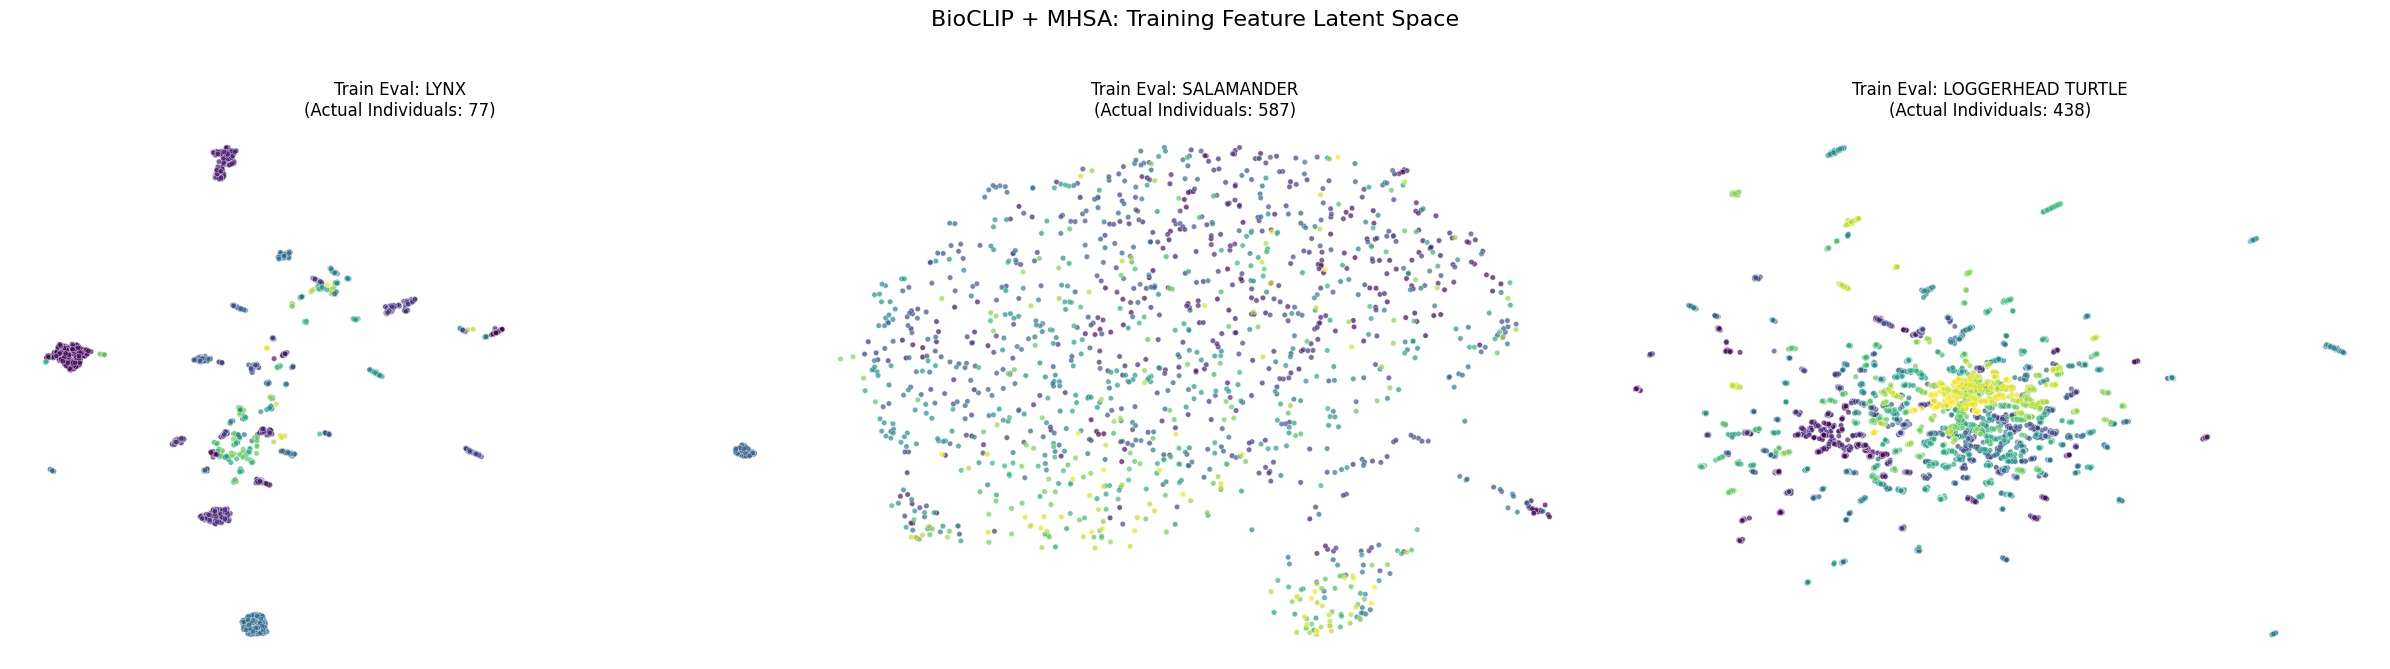

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
import umap


def plot_train_eval_clusters(df, features):
    # Ensure we only plot species present in our features matrix
    species_list = [
        s
        for s in ["lynx", "salamander", "loggerhead turtle"]
        if s in df["species"].unique()
    ]

    fig, axes = plt.subplots(1, len(species_list), figsize=(24, 7))
    if len(species_list) == 1:
        axes = [axes]

    for i, spec in enumerate(species_list):
        # 1. Slice data for this species
        mask = df["species"] == spec
        spec_feats = features[mask]
        spec_df = df[mask]

        # 2. Reduce to 2D for plotting
        # We use slightly higher n_neighbors for the plot to show global structure
        reducer = umap.UMAP(
            n_neighbors=30, min_dist=0.1, n_components=2, random_state=42
        )
        X_2d = reducer.fit_transform(normalize(spec_feats, norm="l2"))

        # 3. Plot
        ax = axes[i]

        # Color by True Identity (Ground Truth)
        # Using a qualitative palette for distinct individuals
        sns.scatterplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            hue=spec_df["identity"],
            ax=ax,
            s=15,
            alpha=0.7,
            legend=False,
            palette="viridis",
        )

        ax.set_title(
            f"Train Eval: {spec.upper()}\n(Actual Individuals: {spec_df['identity'].nunique()})"
        )
        ax.axis("off")

    plt.suptitle("BioCLIP + MHSA: Training Feature Latent Space", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Run the visualization
plot_train_eval_clusters(df_full, features_matrix)

### Eval

In [ ]:
from bioclip_mhsa import ValReIDDataset
# 1. Load test metadata
df_test = metadata[metadata["split"] == "test"].copy().reset_index(drop=True)
df_test['species'] = df_test['species'].fillna('salamander')

# 2. Extract features (Full Test Set)
test_dataset = ValReIDDataset(df_test, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
test_features = []
with torch.no_grad():
    for images in test_loader:
        test_features.append(model(images.to(device)).cpu().numpy())

X_test = np.vstack(test_features)

In [15]:
# Tuning settings based on our internal validation
test_params = {
    "lynx": {"min_dist": 0.15, "n_neighbors": 30},
    "loggerhead turtle": {"min_dist": 0.2, "n_neighbors": 30},
    "salamander": {"min_dist": 0.005, "n_neighbors": 15},
    "lizard": {
        "min_dist": 0.005,
        "n_neighbors": 15,
    },  # Treat lizards like salamanders (high density)
}

all_test_preds = []
all_species_reports = []
for spec in df_test["species"].unique():
    mask = df_test["species"] == spec
    spec_df = df_test[mask].copy()
    spec_feats = X_test[mask]

    p = test_params.get(spec, {"min_dist": 0.1, "n_neighbors": 30})

    # UMAP + HDBSCAN
    reducer = umap.UMAP(
        n_neighbors=p["n_neighbors"],
        min_dist=p["min_dist"],
        n_components=50,
        metric="cosine",
    )
    X_red = reducer.fit_transform(normalize(spec_feats, norm="l2"))

    clusterer = hdbscan.HDBSCAN(min_cluster_size=2, prediction_data=True)
    labels = clusterer.fit_predict(X_red)

    # Format cluster names for submission
    # e.g., 'cluster_TexasHornedLizards_1'
    prefix = f"cluster_{spec}_"
    # Use your logic to map the labels to the specific competition strings here

    spec_df["cluster"] = labels  # Placeholder for the string mapping
    all_test_preds.append(spec_df)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=2)
    labels = clusterer.fit_predict(X_red)

    # 3. Handle noise and compute metrics
    # ... (same relabeling logic as before) ...

    # y_true = spec_df["identity"]
    # ari = adjusted_rand_score(y_true, labels)
    # nmi = normalized_mutual_info_score(y_true, labels)

    all_species_reports.append(
        {
            "Species": spec,
            "Images": len(spec_df),
            # "ARI": round(ari, 3),
            # "NMI": round(nmi, 3),
            # "y_true": len(np.unique(y_true)),
            "y_pred": len(np.unique(labels)),
            "samples": len(labels),
            # "Ratio": round(len(np.unique(labels)) / len(y_true.unique()), 2),
        }
    )
final_submission_df = pd.concat(all_test_preds)

In [20]:
for s in all_species_reports:
    for k,v in s.items():
        print(f"{k}: {v}")
    print("--------")

Species: lynx
Images: 946
y_pred: 65
samples: 946
--------
Species: salamander
Images: 689
y_pred: 84
samples: 689
--------
Species: loggerhead turtle
Images: 500
y_pred: 71
samples: 500
--------
Species: lizard
Images: 274
y_pred: 39
samples: 274
--------


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


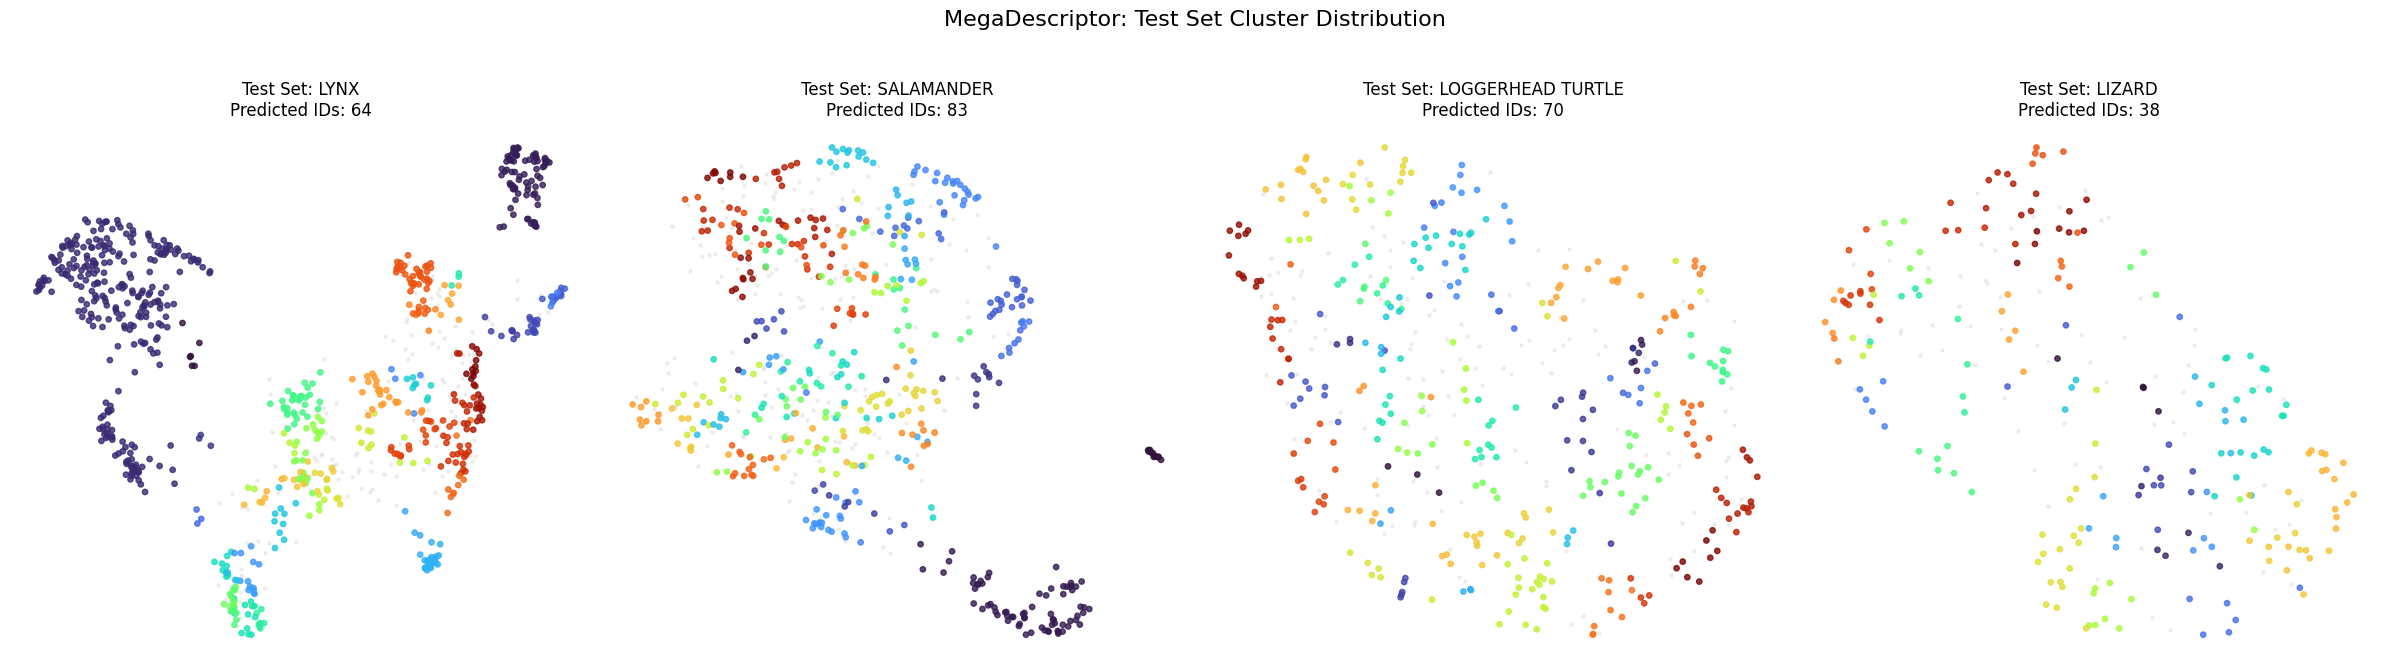

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_test_clusters(df_test, X_test, n_neighbors=30, min_dist=0.1):
    species_list = df_test["species"].unique()
    fig, axes = plt.subplots(1, len(species_list), figsize=(24, 7))
    if len(species_list) == 1:
        axes = [axes]

    for i, spec in enumerate(species_list):
        # 1. Slice data
        mask = df_test["species"] == spec
        spec_feats = X_test[mask]
        # Get the labels we just generated in your loop
        spec_labels = df_test.loc[mask, "cluster"]

        # 2. Project to 2D for visualization
        # We use a standard viz setting here (min_dist 0.1) to see the 'natural' spread
        viz_reducer = umap.UMAP(
            n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=42
        )
        X_2d = viz_reducer.fit_transform(normalize(spec_feats, norm="l2"))

        # 3. Plot
        ax = axes[i]

        # Plot Noise (-1) in light gray
        noise_mask = spec_labels == -1
        if noise_mask.any():
            ax.scatter(
                X_2d[noise_mask, 0],
                X_2d[noise_mask, 1],
                c="lightgray",
                s=5,
                alpha=0.3,
                label="Noise",
            )

        # Plot valid clusters
        clustered_mask = ~noise_mask
        if clustered_mask.any():
            scatter = ax.scatter(
                X_2d[clustered_mask, 0],
                X_2d[clustered_mask, 1],
                c=spec_labels[clustered_mask],
                cmap="turbo",
                s=15,
                alpha=0.8,
            )

        ax.set_title(
            f"Test Set: {spec.upper()}\nPredicted IDs: {len(np.unique(spec_labels[clustered_mask]))}"
        )
        ax.axis("off")

    plt.suptitle("MegaDescriptor: Test Set Cluster Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Run the plot
plot_test_clusters(final_submission_df, X_test)

In [16]:
import pandas as pd

# 1. Create a clean copy for the final format
submission_df = final_submission_df.copy()


# 2. Ensure IDs are formatted as strings exactly as Kaggle expects
# Standard AnimalCLEF format: cluster_{species}_{cluster_id}
# We handle the noise (-1) by giving them a unique "singleton" cluster ID
def format_prediction(row):
    species_name = row["species"].replace(" ", "")
    species_map = {
        "lynx":"cluster_LynxID2025_", 
        "loggerheadturtle":"cluster_SeaTurtleID2022_", 
        "lizard":"cluster_TexasHornedLizards_", 
        "salamander":"cluster_SalamanderID2025_"
    }

    if row["cluster"] == -1:
        # Assign a unique cluster ID for noise points so they don't all merge
        return f"{species_map[species_name]}noise_{row['image_id']}"
    else:
        return f"{species_map[species_name]}{int(row['cluster'])}"


submission_df["cluster"] = submission_df.apply(format_prediction, axis=1)

# 3. Keep only the required columns
# Usually 'image_id' and 'prediction'
final_csv = submission_df[["image_id", "cluster"]]

# 4. Save to the current directory
final_csv.to_csv("submission_16apr_7.csv", index=False)

print(f"Successfully saved {len(final_csv)} predictions to submission csv")
print("Preview of submission:")
print(final_csv.head())

Successfully saved 2409 predictions to submission csv
Preview of submission:
   image_id                      cluster
0         3        cluster_LynxID2025_93
1         5        cluster_LynxID2025_22
2        12        cluster_LynxID2025_25
3        13        cluster_LynxID2025_57
4        18  cluster_LynxID2025_noise_18


In [60]:
# Tuning settings based on our internal validation
test_params = {
    "lynx": {"min_dist": 0.2, "n_neighbors": 35},
    "loggerhead turtle": {"min_dist": 0.15, "n_neighbors": 25},
    "salamander": {"min_dist": 0.01, "n_neighbors": 20},
    "lizard": {
        "min_dist": 0.15,
        "n_neighbors": 25,
    },  # Treat lizards like salamanders (high density)
}

all_test_preds = []
all_species_reports = []
for spec in df_test["species"].unique():
    mask = df_test["species"] == spec
    spec_df = df_test[mask].copy()
    spec_feats = X_test[mask]

    p = test_params.get(spec, {"min_dist": 0.1, "n_neighbors": 30})

    # UMAP + HDBSCAN
    reducer = umap.UMAP(
        n_neighbors=p["n_neighbors"],
        min_dist=p["min_dist"],
        n_components=50,
        metric="cosine",
    )
    X_red = reducer.fit_transform(normalize(spec_feats, norm="l2"))

    clusterer = hdbscan.HDBSCAN(min_cluster_size=2, prediction_data=True)
    labels = clusterer.fit_predict(X_red)

    # Format cluster names for submission
    # e.g., 'cluster_TexasHornedLizards_1'
    prefix = f"cluster_{spec}_"
    # Use your logic to map the labels to the specific competition strings here

    spec_df["cluster"] = labels  # Placeholder for the string mapping
    all_test_preds.append(spec_df)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=2)
    labels = clusterer.fit_predict(X_red)

    # 3. Handle noise and compute metrics
    # ... (same relabeling logic as before) ...

    # y_true = spec_df["identity"]
    # ari = adjusted_rand_score(y_true, labels)
    # nmi = normalized_mutual_info_score(y_true, labels)

    all_species_reports.append(
        {
            "Species": spec,
            "Images": len(spec_df),
            # "ARI": round(ari, 3),
            # "NMI": round(nmi, 3),
            # "y_true": len(np.unique(y_true)),
            "y_pred": len(np.unique(labels)),
            "samples": len(labels),
            # "Ratio": round(len(np.unique(labels)) / len(y_true.unique()), 2),
        }
    )
final_submission_df = pd.concat(all_test_preds)

Using column 'cluster' for labels...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


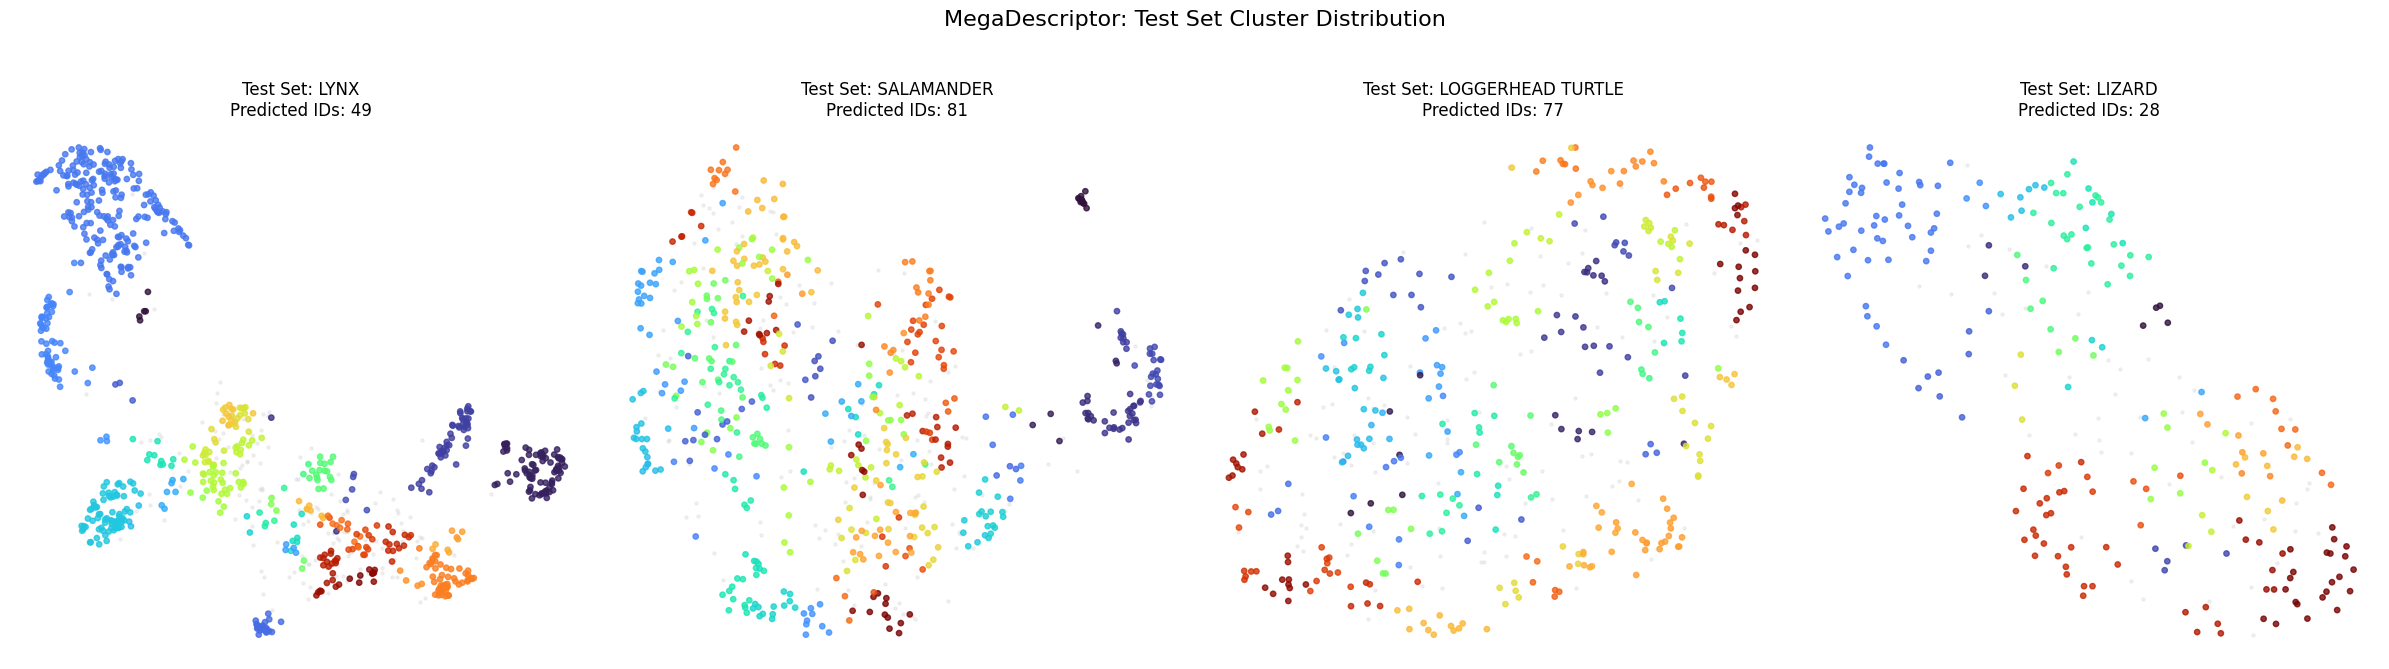

In [61]:
def plot_test_clusters(df_test, X_test, n_neighbors=30, min_dist=0.1):
    # Determine the correct column name (cluster or cluster_label)
    label_col = "cluster" if "cluster" in df_test.columns else "cluster_label"
    print(f"Using column '{label_col}' for labels...")

    species_list = df_test["species"].unique()
    fig, axes = plt.subplots(1, len(species_list), figsize=(24, 7))
    if len(species_list) == 1:
        axes = [axes]

    for i, spec in enumerate(species_list):
        mask = df_test["species"] == spec
        spec_feats = X_test[mask]
        spec_labels = df_test.loc[mask, label_col]  # Using the detected column name

        # Project to 2D
        viz_reducer = umap.UMAP(
            n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=42
        )
        X_2d = viz_reducer.fit_transform(normalize(spec_feats, norm="l2"))

        ax = axes[i]

        # Plot Noise and Clusters
        noise_mask = spec_labels == -1
        if noise_mask.any():
            ax.scatter(
                X_2d[noise_mask, 0], X_2d[noise_mask, 1], c="lightgray", s=5, alpha=0.3
            )

        clustered_mask = ~noise_mask
        if clustered_mask.any():
            ax.scatter(
                X_2d[clustered_mask, 0],
                X_2d[clustered_mask, 1],
                c=spec_labels[clustered_mask],
                cmap="turbo",
                s=15,
                alpha=0.8,
            )

        ax.set_title(
            f"Test Set: {spec.upper()}\nPredicted IDs: {len(np.unique(spec_labels[clustered_mask]))}"
        )
        ax.axis("off")

    plt.suptitle("MegaDescriptor: Test Set Cluster Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Run the plot
plot_test_clusters(final_submission_df, X_test)

In [62]:
for s in all_species_reports:
    for k, v in s.items():
        print(f"{k}: {v}")
    print("--------")

Species: lynx
Images: 946
y_pred: 50
samples: 946
--------
Species: salamander
Images: 689
y_pred: 82
samples: 689
--------
Species: loggerhead turtle
Images: 500
y_pred: 78
samples: 500
--------
Species: lizard
Images: 274
y_pred: 29
samples: 274
--------


In [64]:
import pandas as pd

# 1. Create a clean copy for the final format
submission_df = final_submission_df.copy()


# 2. Ensure IDs are formatted as strings exactly as Kaggle expects
# Standard AnimalCLEF format: cluster_{species}_{cluster_id}
# We handle the noise (-1) by giving them a unique "singleton" cluster ID
def format_prediction(row):
    species_name = row["species"].replace(" ", "")
    species_map = {
        "lynx": "cluster_LynxID2025_",
        "loggerheadturtle": "cluster_SeaTurtleID2022_",
        "lizard": "cluster_TexasHornedLizards_",
        "salamander": "cluster_SalamanderID2025_",
    }

    if row["cluster"] == -1:
        # Assign a unique cluster ID for noise points so they don't all merge
        return f"{species_map[species_name]}noise_{row['image_id']}"
    else:
        return f"{species_map[species_name]}{int(row['cluster'])}"


submission_df["cluster"] = submission_df.apply(format_prediction, axis=1)

# 3. Keep only the required columns
# Usually 'image_id' and 'prediction'
final_csv = submission_df[["image_id", "cluster"]]

# 4. Save to the current directory
final_csv.to_csv("submission_17apr_10.csv", index=False)

print(f"Successfully saved {len(final_csv)} predictions to submission csv")
print("Preview of submission:")
print(final_csv.head())

Successfully saved 2409 predictions to submission csv
Preview of submission:
   image_id                cluster
0         3  cluster_LynxID2025_44
1         5  cluster_LynxID2025_13
2        12   cluster_LynxID2025_7
3        13  cluster_LynxID2025_20
4        18   cluster_LynxID2025_3


Using column 'cluster' for labels...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


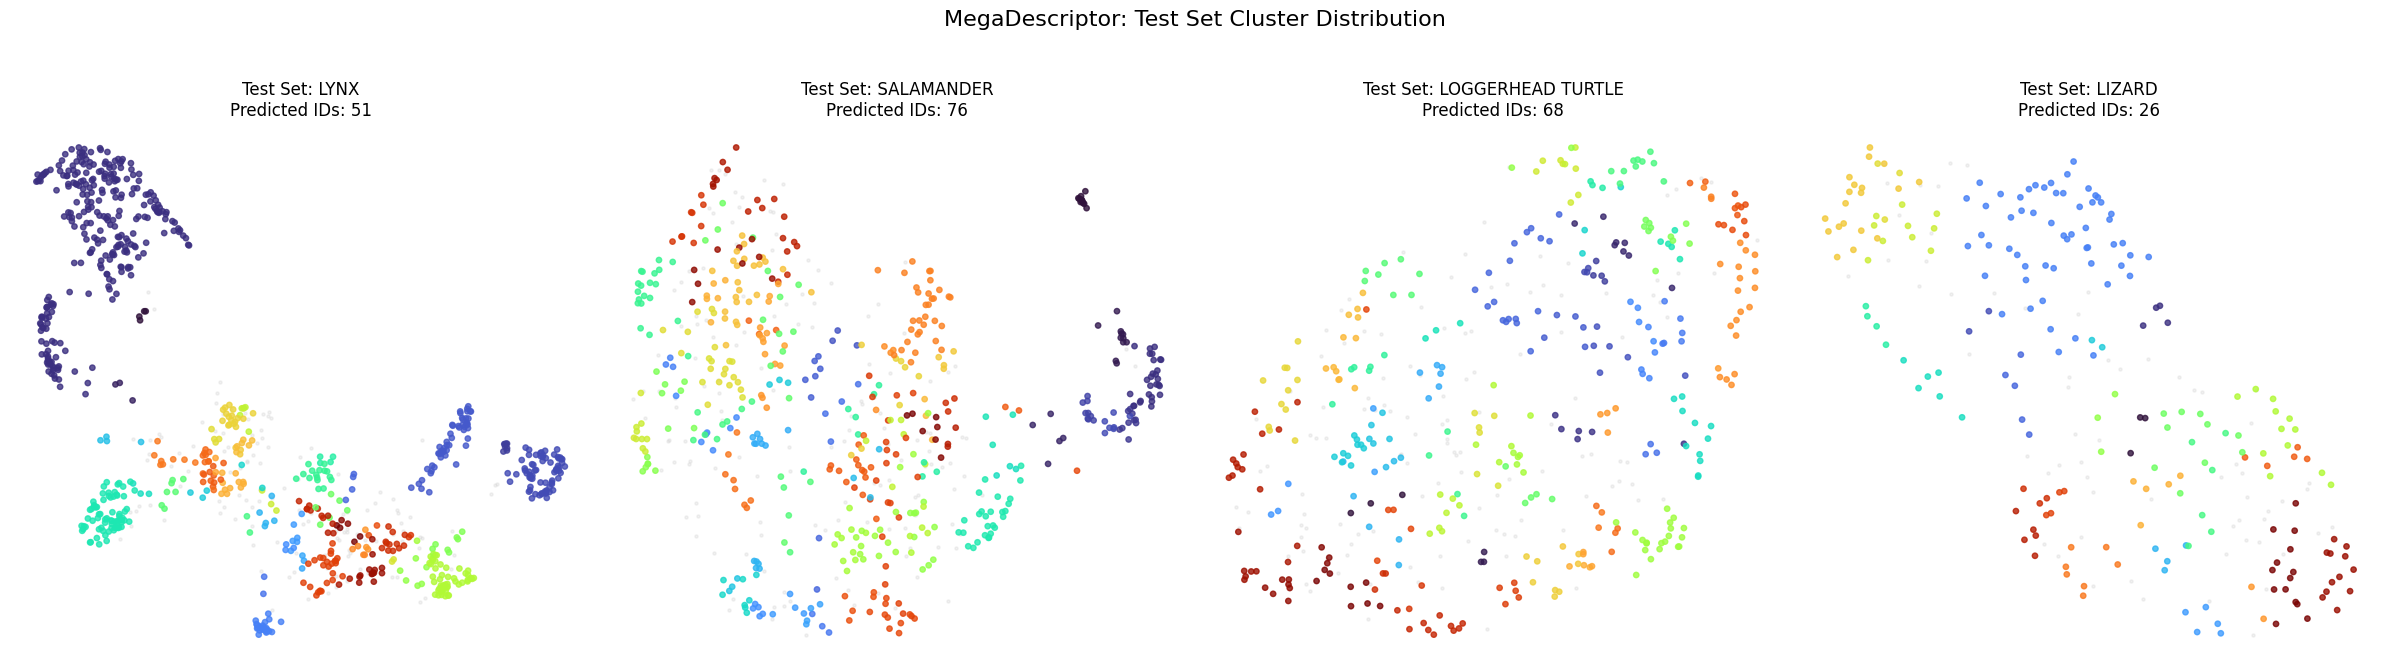

Species: lynx
Images: 946
y_pred: 52
samples: 946
--------
Species: salamander
Images: 689
y_pred: 77
samples: 689
--------
Species: loggerhead turtle
Images: 500
y_pred: 69
samples: 500
--------
Species: lizard
Images: 274
y_pred: 27
samples: 274
--------
Successfully saved 2409 predictions to submission csv
Preview of submission:
   image_id                cluster
0         3  cluster_LynxID2025_42
1         5  cluster_LynxID2025_17
2        12   cluster_LynxID2025_2
3        13  cluster_LynxID2025_19
4        18   cluster_LynxID2025_5


In [74]:
# Tuning settings based on our internal validation
test_params = {
    "lynx": {"min_dist": 0.2, "n_neighbors": 40},
    "loggerhead turtle": {"min_dist": 0.18, "n_neighbors": 25},
    "salamander": {"min_dist": 0.02, "n_neighbors": 18},
    "lizard": {
        "min_dist": 0.15,
        "n_neighbors": 15,
    },  # Treat lizards like salamanders (high density)
}

all_test_preds = []
all_species_reports = []
for spec in df_test["species"].unique():
    mask = df_test["species"] == spec
    spec_df = df_test[mask].copy()
    spec_feats = X_test[mask]

    p = test_params.get(spec, {"min_dist": 0.1, "n_neighbors": 30})

    # UMAP + HDBSCAN
    reducer = umap.UMAP(
        n_neighbors=p["n_neighbors"],
        min_dist=p["min_dist"],
        n_components=50,
        metric="cosine",
    )
    X_red = reducer.fit_transform(normalize(spec_feats, norm="l2"))

    clusterer = hdbscan.HDBSCAN(min_cluster_size=2, prediction_data=True)
    labels = clusterer.fit_predict(X_red)

    # Format cluster names for submission
    # e.g., 'cluster_TexasHornedLizards_1'
    prefix = f"cluster_{spec}_"
    # Use your logic to map the labels to the specific competition strings here

    spec_df["cluster"] = labels  # Placeholder for the string mapping
    all_test_preds.append(spec_df)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=2)
    labels = clusterer.fit_predict(X_red)

    # 3. Handle noise and compute metrics
    # ... (same relabeling logic as before) ...

    # y_true = spec_df["identity"]
    # ari = adjusted_rand_score(y_true, labels)
    # nmi = normalized_mutual_info_score(y_true, labels)

    all_species_reports.append(
        {
            "Species": spec,
            "Images": len(spec_df),
            # "ARI": round(ari, 3),
            # "NMI": round(nmi, 3),
            # "y_true": len(np.unique(y_true)),
            "y_pred": len(np.unique(labels)),
            "samples": len(labels),
            # "Ratio": round(len(np.unique(labels)) / len(y_true.unique()), 2),
        }
    )
final_submission_df = pd.concat(all_test_preds)


def plot_test_clusters(df_test, X_test, n_neighbors=30, min_dist=0.1):
    # Determine the correct column name (cluster or cluster_label)
    label_col = "cluster" if "cluster" in df_test.columns else "cluster_label"
    print(f"Using column '{label_col}' for labels...")

    species_list = df_test["species"].unique()
    fig, axes = plt.subplots(1, len(species_list), figsize=(24, 7))
    if len(species_list) == 1:
        axes = [axes]

    for i, spec in enumerate(species_list):
        mask = df_test["species"] == spec
        spec_feats = X_test[mask]
        spec_labels = df_test.loc[mask, label_col]  # Using the detected column name

        # Project to 2D
        viz_reducer = umap.UMAP(
            n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=42
        )
        X_2d = viz_reducer.fit_transform(normalize(spec_feats, norm="l2"))

        ax = axes[i]

        # Plot Noise and Clusters
        noise_mask = spec_labels == -1
        if noise_mask.any():
            ax.scatter(
                X_2d[noise_mask, 0], X_2d[noise_mask, 1], c="lightgray", s=5, alpha=0.3
            )

        clustered_mask = ~noise_mask
        if clustered_mask.any():
            ax.scatter(
                X_2d[clustered_mask, 0],
                X_2d[clustered_mask, 1],
                c=spec_labels[clustered_mask],
                cmap="turbo",
                s=15,
                alpha=0.8,
            )

        ax.set_title(
            f"Test Set: {spec.upper()}\nPredicted IDs: {len(np.unique(spec_labels[clustered_mask]))}"
        )
        ax.axis("off")

    plt.suptitle("MegaDescriptor: Test Set Cluster Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Run the plot
plot_test_clusters(final_submission_df, X_test)

for s in all_species_reports:
    for k, v in s.items():
        print(f"{k}: {v}")
    print("--------")


import pandas as pd

# 1. Create a clean copy for the final format
submission_df = final_submission_df.copy()


# 2. Ensure IDs are formatted as strings exactly as Kaggle expects
# Standard AnimalCLEF format: cluster_{species}_{cluster_id}
# We handle the noise (-1) by giving them a unique "singleton" cluster ID
def format_prediction(row):
    species_name = row["species"].replace(" ", "")
    species_map = {
        "lynx": "cluster_LynxID2025_",
        "loggerheadturtle": "cluster_SeaTurtleID2022_",
        "lizard": "cluster_TexasHornedLizards_",
        "salamander": "cluster_SalamanderID2025_",
    }

    if row["cluster"] == -1:
        # Assign a unique cluster ID for noise points so they don't all merge
        return f"{species_map[species_name]}noise_{row['image_id']}"
    else:
        return f"{species_map[species_name]}{int(row['cluster'])}"


submission_df["cluster"] = submission_df.apply(format_prediction, axis=1)

# 3. Keep only the required columns
# Usually 'image_id' and 'prediction'
final_csv = submission_df[["image_id", "cluster"]]

# 4. Save to the current directory
final_csv.to_csv("submission_17apr_11.csv", index=False)

print(f"Successfully saved {len(final_csv)} predictions to submission csv")
print("Preview of submission:")
print(final_csv.head())

In [45]:
!uv pip install transformers

Resolved 28 packages in 276ms                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)--------------     0 B/9.76 MiB            
⠙ Preparing packages... (0/1)-------------- 16.00 KiB/9.76 MiB          
⠙ Preparing packages... (0/1)-------------- 32.00 KiB/9.76 MiB          
⠙ Preparing packages... (0/1)-------------- 48.00 KiB/9.76 MiB          
⠙ Preparing packages... (0/1)-------------- 60.99 KiB/9.76 MiB          
⠙ Preparing packages... (0/1)-------------- 76.99 KiB/9.76 MiB          
⠙ Preparing packages... (0/1)-------------- 92.99 KiB/9.76 MiB          
⠙ Preparing packages... (0/1)-------------- 108.99 KiB/9.76 MiB         
⠙ Preparing packages... (0/1)-------------- 124.99 KiB/9.76 MiB         
⠙ Preparing packages... (0/1)-------------- 140.99 KiB/9.76 MiB         
⠙ Preparing packages... (0/1)-------------- 156.99 KiB/9.76 MiB         
⠙ Preparing packages... (0/1)-------------- 17

In [46]:
from transformers import AutoModel
import torch

# Pro-tip: msv3 is the latest version (64 species vs 54 in msv2)
model_tag = "conservationxlabs/miewid-msv3"

device = (
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)

# trust_remote_code is the key here to bypass that KeyError
miewid_model = AutoModel.from_pretrained(model_tag, trust_remote_code=True).to(device)
miewid_model.eval()

print(f"MiewID {model_tag} loaded successfully on {device}!")

Building Model Backbone for efficientnetv2_rw_m model
config.model_name efficientnetv2_rw_m
model_name efficientnetv2_rw_m


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py:2589: UserWarning: for conv_stem.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/

final_in_features 2152


Loading weights: 100%|██████████| 1210/1210 [00:00<00:00, 9057.78it/s]


MiewID conservationxlabs/miewid-msv3 loaded successfully on mps!


In [56]:
from torchvision import transforms

# MiewID-v3 is optimized for 440x440 resolution.
# We use the standard ImageNet normalization constants.
miewid_transform = transforms.Compose(
    [
        transforms.Resize((440, 440)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
@torch.no_grad()
def extract_miewid_features(image_paths):
    features = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        # MiewID v3 is optimized for 440x440 (or 448x448)
        img_tensor = miewid_transform(img).unsqueeze(0).to(device)

        # Forward pass
        output = miewid_model(img_tensor)

        # MiewID usually returns the embedding directly or in 'embeddings'
        # If it returns a tensor, use that. If a dict, grab the key.
        if isinstance(output, torch.Tensor):
            emb = output
        else:
            emb = output.embeddings  # Standard for this specific hub model

        features.append(emb.cpu().numpy().squeeze())

    return np.array(features)

Applying k-reciprocal reranking to lynx...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Applying k-reciprocal reranking to salamander...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Applying k-reciprocal reranking to loggerhead turtle...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Applying k-reciprocal reranking to lizard...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


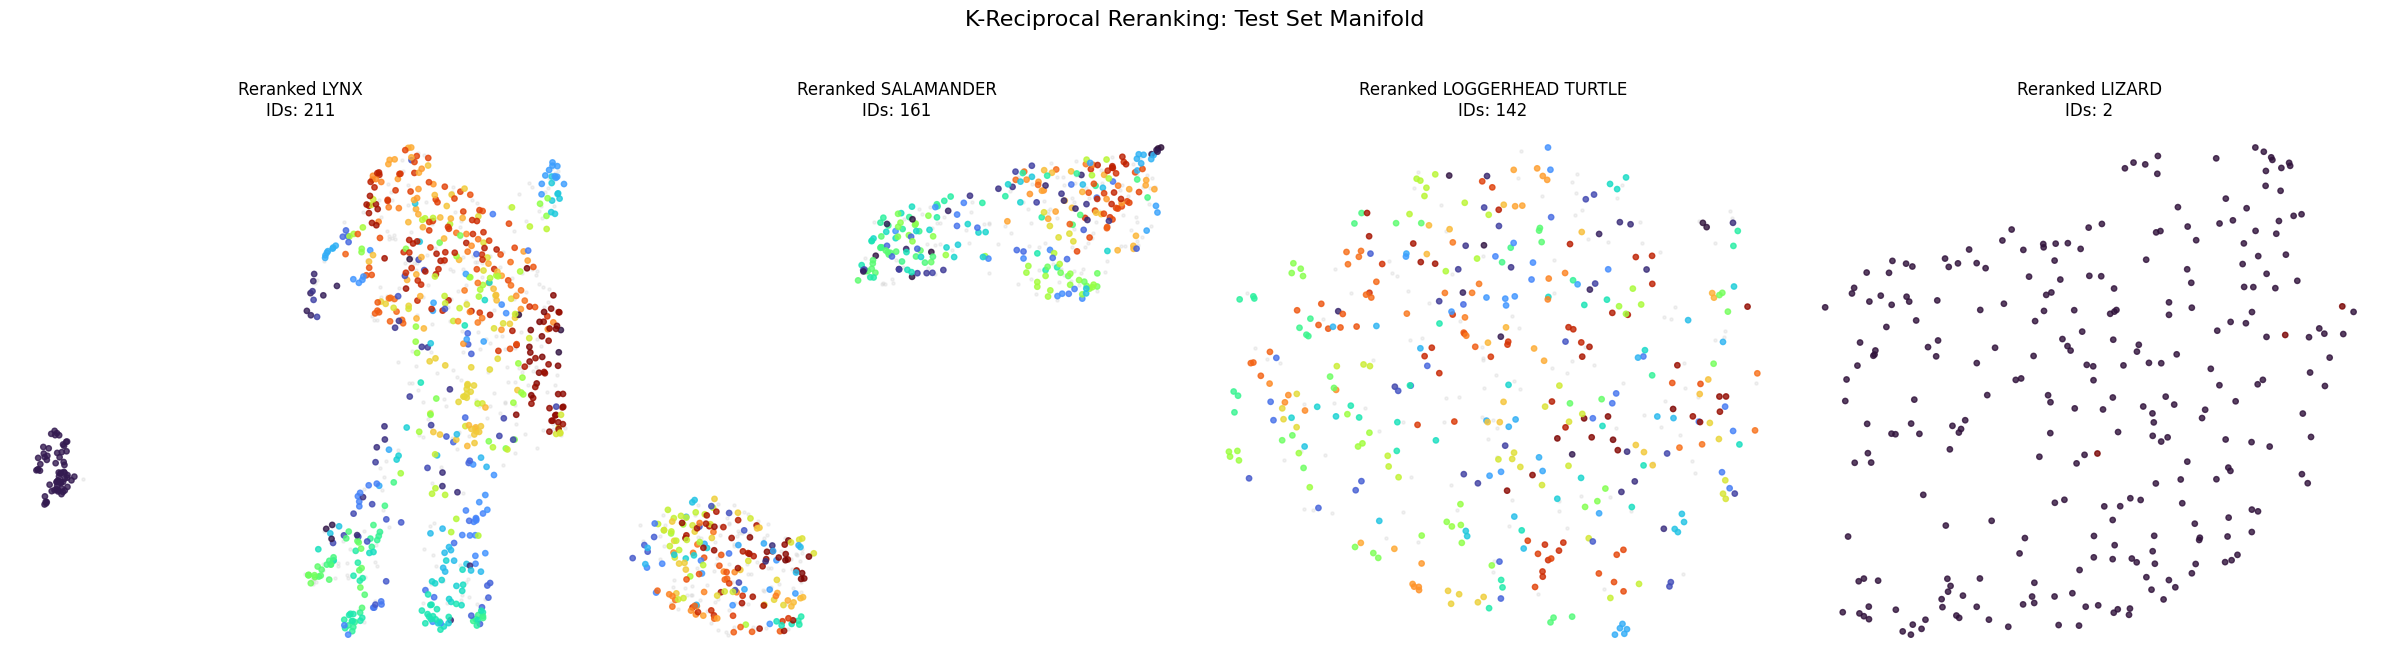

In [60]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import OPTICS
import umap
import hdbscan
import matplotlib.pyplot as plt


def k_reciprocal_rerank(features, k1=20, k2=6, lambda_value=0.3):
    # Initial Euclidean distances
    dist = euclidean_distances(features, features)
    dist = np.power(dist, 2).astype(np.float32)

    n = dist.shape[0]
    indices = np.argsort(dist, axis=1)

    # Compute reciprocity-based manifold distance
    v = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        forward_k = indices[i, : k1 + 1]
        for j in forward_k:
            backward_k = indices[j, : k1 + 1]
            if i in backward_k:
                v[i, j] = np.exp(-dist[i, j])

    jaccard_dist = euclidean_distances(v, v)
    final_dist = (1 - lambda_value) * dist + lambda_value * jaccard_dist
    return final_dist


def plot_reranked_clusters(df_test, X_test, params):
    species_list = df_test["species"].unique()
    fig, axes = plt.subplots(1, len(species_list), figsize=(24, 7))
    if len(species_list) == 1:
        axes = [axes]

    for i, spec in enumerate(species_list):
        mask = df_test["species"] == spec
        spec_feats = X_test[mask]

        print(f"Applying k-reciprocal reranking to {spec}...")
        # 1. Rerank distances
        reranked_dist = k_reciprocal_rerank(spec_feats, k1=20, k2=6)

        # 2. UMAP with precomputed distance matrix
        viz_reducer = umap.UMAP(
            n_neighbors=params.get(spec, {}).get("n_neighbors", 25),
            min_dist=params.get(spec, {}).get("min_dist", 0.1),
            metric="precomputed",  # Use our reranked matrix
            n_components=2,
            random_state=42,
        )
        X_2d = viz_reducer.fit_transform(reranked_dist)

        # 3. Cluster for visualization labels
        # clusterer = hdbscan.HDBSCAN(
        #     min_cluster_size=2, min_samples=1, cluster_selection_method="leaf"
        # )

        labels = clusterer.fit_predict(reranked_dist)

        ax = axes[i]
        noise_mask = labels == -1
        if noise_mask.any():
            ax.scatter(
                X_2d[noise_mask, 0], X_2d[noise_mask, 1], c="lightgray", s=5, alpha=0.3
            )

        clustered_mask = ~noise_mask
        if clustered_mask.any():
            ax.scatter(
                X_2d[clustered_mask, 0],
                X_2d[clustered_mask, 1],
                c=labels[clustered_mask],
                cmap="turbo",
                s=15,
                alpha=0.8,
            )

        ax.set_title(
            f"Reranked {spec.upper()}\nIDs: {len(np.unique(labels[clustered_mask]))}"
        )
        ax.axis("off")

    plt.suptitle("K-Reciprocal Reranking: Test Set Manifold", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

test_params = {
    "lynx": {"min_dist": 0.2, "n_neighbors": 40},
    "loggerhead turtle": {"min_dist": 0.2, "n_neighbors": 25},
    "salamander": {"min_dist": 0.2, "n_neighbors": 40},
    "lizard": {
        "min_dist": 0.01,
        "n_neighbors": 20,
    },  # Treat lizards like salamanders (high density)
}
# --- STEP 1: Feature Extraction (The "Encoder" Stage) ---
# Assuming 'image_paths' is a list of paths corresponding to your final_submission_df

# print("Extracting MiewID features... this may take a moment.")
# import os
# image_paths = df_test["image_id"].apply(lambda x: os.path.join(os.getcwd(),"data/val/images", f"{x}.jpg"))
# X_miewid = extract_miewid_features(image_paths)

# (Optional) If you want to use the Triple Fusion we discussed:
# X_test = (normalize(X_miewid) * 0.4) + (normalize(X_bioclip) * 0.6)
# X_test = normalize(X_test)

# --- STEP 2: Visualization and Clustering ---
# Now pass the MiewID features into your plotter
plot_reranked_clusters(final_submission_df, X_miewid, test_params)
# Run the visual check
# plot_reranked_clusters(final_submission_df, X_test, test_params)
# Save after extraction
np.save("X_miewid_features.npy", X_miewid)

# Later, you can just load them in seconds:
# X_miewid = np.load('X_miewid_features.npy')

In [24]:
import pandas as pd
import numpy as np

# 1. Setup final containers
all_reranked_preds = []

# 2. Species Map for AnimalCLEF
species_map = {
    "lynx": "cluster_LynxID2025_",
    "loggerheadturtle": "cluster_SeaTurtleID2022_",
    "lizard": "cluster_TexasHornedLizards_",
    "salamander": "cluster_SalamanderID2025_",
}

# 3. Process each species with the Reranking + UMAP + HDBSCAN pipeline
for spec in df_test["species"].unique():
    mask = df_test["species"] == spec
    spec_df = df_test[mask].copy()
    spec_feats = X_test[mask]

    # a. K-Reciprocal Reranking (The "Secret Sauce")
    print(f"Reranking {spec}...")
    reranked_dist = k_reciprocal_rerank(spec_feats, k1=20, k2=6)

    # b. UMAP with the reranked distance matrix
    p = test_params.get(spec, {"min_dist": 0.1, "n_neighbors": 25})
    reducer = umap.UMAP(
        n_neighbors=p["n_neighbors"],
        min_dist=p["min_dist"],
        metric="precomputed",
        n_components=50,
        random_state=42,
    )
    X_red = reducer.fit_transform(reranked_dist)

    # c. HDBSCAN
    clusterer = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1)
    labels = clusterer.fit_predict(X_red)

    # d. Formatting
    spec_name_key = spec.replace(" ", "")
    prefix = species_map.get(spec_name_key, f"cluster_{spec_name_key}_")

    formatted_clusters = []
    for idx, label in enumerate(labels):
        if label == -1:
            # Unique ID for noise points to maximize ARI precision
            formatted_clusters.append(f"{prefix}noise_{spec_df.iloc[idx]['image_id']}")
        else:
            formatted_clusters.append(f"{prefix}{int(label)}")

    spec_df["cluster"] = formatted_clusters
    all_reranked_preds.append(spec_df[["image_id", "cluster"]])

# 4. Final CSV Export
final_csv = pd.concat(all_reranked_preds)
filename = "submission_20apr_reranked_optic.csv"
final_csv.to_csv(filename, index=False)

print(f"\nSuccessfully saved to {filename}")
print(f"Total Rows: {len(final_csv)}")
print(final_csv.head())

Reranking lynx...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reranking salamander...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reranking loggerhead turtle...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reranking lizard...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Successfully saved to submission_20apr_reranked_optic.csv
Total Rows: 2409
   image_id                 cluster
0         3  cluster_LynxID2025_220
1         5  cluster_LynxID2025_174
2        12  cluster_LynxID2025_153
3        13  cluster_LynxID2025_182
4        18   cluster_LynxID2025_63


Processing lynx...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processing salamander...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processing loggerhead turtle...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processing lizard...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


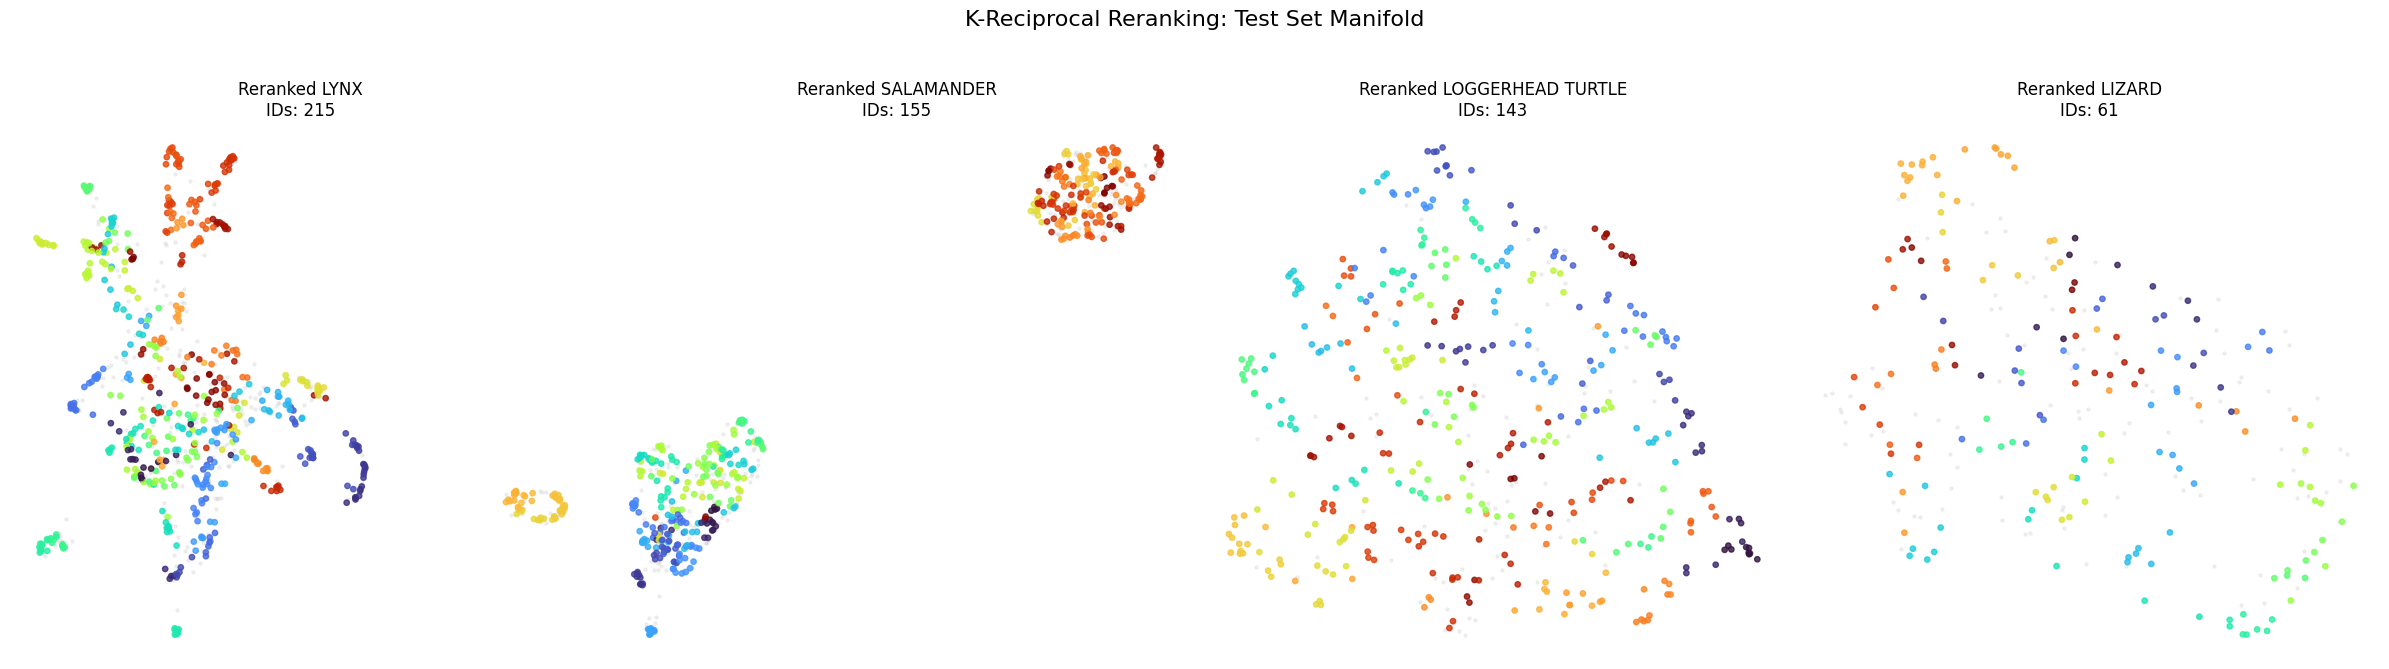

In [79]:
def plot_reranked_clusters(df_test, X_test, params):
    species_list = df_test["species"].unique()
    fig, axes = plt.subplots(1, len(species_list), figsize=(24, 7))
    if len(species_list) == 1:
        axes = [axes]

    for i, spec in enumerate(species_list):
        mask = df_test["species"] == spec
        # It's best practice to normalize features before Euclidean/Reranking
        spec_feats = normalize(X_test[mask], norm='l2') 

        print(f"Processing {spec}...")

        # Standardize key for the params dictionary
        spec_key = spec.lower().strip()
        p = params.get(spec_key, {"min_dist": 0.1, "n_neighbors": 25})

        # 1. Rerank
        reranked_dist = k_reciprocal_rerank(spec_feats, k1=20, k2=6)

        # 2. UMAP
        viz_reducer = umap.UMAP(
            n_neighbors=p["n_neighbors"],
            min_dist=p["min_dist"],
            metric="precomputed",
            n_components=2,
            random_state=42,
        )
        X_2d = viz_reducer.fit_transform(reranked_dist)

        # 3. Clusterer Definition (FIXED: Moved inside the loop)
        clusterer = OPTICS(
            min_samples=2,
            xi=0.015, 
            metric="precomputed",
            cluster_method="xi"
        )
        labels = clusterer.fit_predict(reranked_dist)

        # --- Plotting Logic ---
        ax = axes[i]
        noise_mask = labels == -1

        # Plot Noise
        if noise_mask.any():
            ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c="lightgray", s=5, alpha=0.3)

        # Plot Clusters
        clustered_mask = ~noise_mask
        if clustered_mask.any():
            ax.scatter(
                X_2d[clustered_mask, 0],
                X_2d[clustered_mask, 1],
                c=labels[clustered_mask],
                cmap="turbo",
                s=15,
                alpha=0.8,
            )

        ax.set_title(f"Reranked {spec.upper()}\nIDs: {len(np.unique(labels[clustered_mask]))}")
        ax.axis("off")

    plt.suptitle("K-Reciprocal Reranking: Test Set Manifold", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- STEP 3: Run ---
test_params = {
    "lynx": {"min_dist": 0.1, "n_neighbors": 30},
    "loggerhead turtle": {"min_dist": 0.1, "n_neighbors": 35},
    "salamander": {"min_dist": 0.06, "n_neighbors": 30},
    "lizard": {
        "min_dist": 0.16,
        "n_neighbors": 20,
    },  # Treat lizards like salamanders (high density)
}
plot_reranked_clusters(final_submission_df, X_miewid, test_params)

In [80]:
import pandas as pd
import numpy as np

# 1. Setup final containers
all_reranked_preds = []

# 2. Species Map for AnimalCLEF
species_map = {
    "lynx": "cluster_LynxID2025_",
    "loggerheadturtle": "cluster_SeaTurtleID2022_",
    "lizard": "cluster_TexasHornedLizards_",
    "salamander": "cluster_SalamanderID2025_",
}

# 3. Process each species with the Reranking + UMAP + HDBSCAN pipeline
for spec in df_test["species"].unique():
    mask = df_test["species"] == spec
    spec_df = df_test[mask].copy()
    spec_feats = X_test[mask]

    # a. K-Reciprocal Reranking (The "Secret Sauce")
    print(f"Reranking {spec}...")
    reranked_dist = k_reciprocal_rerank(spec_feats, k1=20, k2=6, lambda_value=0.7)

    # b. UMAP with the reranked distance matrix
    p = test_params.get(spec, {"min_dist": 0.1, "n_neighbors": 25})
    reducer = umap.UMAP(
        n_neighbors=p["n_neighbors"],
        min_dist=p["min_dist"],
        metric="precomputed",
        n_components=50,
        random_state=42,
    )
    X_red = reducer.fit_transform(reranked_dist)

    # c. HDBSCAN
    clusterer = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1)
    labels = clusterer.fit_predict(X_red)

    # d. Formatting
    spec_name_key = spec.replace(" ", "")
    prefix = species_map.get(spec_name_key, f"cluster_{spec_name_key}_")

    formatted_clusters = []
    for idx, label in enumerate(labels):
        if label == -1:
            # Unique ID for noise points to maximize ARI precision
            formatted_clusters.append(f"{prefix}noise_{spec_df.iloc[idx]['image_id']}")
        else:
            formatted_clusters.append(f"{prefix}{int(label)}")

    spec_df["cluster"] = formatted_clusters
    all_reranked_preds.append(spec_df[["image_id", "cluster"]])

# 4. Final CSV Export
final_csv = pd.concat(all_reranked_preds)
filename = "submission_20apr_reranked_optic_miewid_bioclip.csv"
final_csv.to_csv(filename, index=False)

print(f"\nSuccessfully saved to {filename}")
print(f"Total Rows: {len(final_csv)}")
print(final_csv.head())

Reranking lynx...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reranking salamander...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reranking loggerhead turtle...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reranking lizard...


/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ElliotPhua/HiddenDesktop/somethingSoon/SUTD/Y4S8/CV/Project/apr14/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Successfully saved to submission_20apr_reranked_optic_miewid_bioclip.csv
Total Rows: 2409
   image_id                     cluster
0         3      cluster_LynxID2025_207
1         5  cluster_LynxID2025_noise_5
2        12      cluster_LynxID2025_112
3        13      cluster_LynxID2025_132
4        18       cluster_LynxID2025_68
